# Random Forest Model: NHS PROMs Knee Replacement

Extracts only the Random Forest sections.

- **Class 0** = Good Outcome (~82%)
- **Class 1** = Poor Outcome (~18%)

## Step 1: Import Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Scikit-learn: Models and utilities
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_validate,       # For cross-validation
    StratifiedKFold,      # For stratified splits (preserves class distribution)
)
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    make_scorer
)

# Imbalanced-learn: For SMOTE
print("All libraries imported successfully!")
from sklearn.model_selection import learning_curve, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import average_precision_score

All libraries imported successfully!


## Step 2: Load the Data

In [3]:
# The used file is the earlier version of WO provider; called incl. This includes the provider code and excludes the new variables like
# comorbidity count, oksfunctionscale, oks pain scale and oks daily life scale

# Define file paths
DATA_PATH = '../data/cleaned/'

# Load training data
X_train = pd.read_parquet(DATA_PATH + 'X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet(DATA_PATH + 'y_train.parquet')

# Load test data (for final evaluation only!)
X_test = pd.read_parquet(DATA_PATH + 'X_test_encoded_wo_provider.parquet')
y_test = pd.read_parquet(DATA_PATH + 'y_test.parquet')

# Convert y to 1D array (required by sklearn)
# The .values.ravel() converts from DataFrame to 1D numpy array
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"\nFeature names: {list(X_train.columns[:10])}... (showing first 10)")

Training set: 105905 samples, 57 features
Test set: 26477 samples, 57 features

Feature names: ['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation']... (showing first 10)


## Step 2b: Handle String Columns (One-Hot Encoding)

In [4]:
# Step 2b: Handle String Columns (One-Hot Encoding)
# StandardScaler requires numeric data, so we need to encode any string columns

from sklearn.preprocessing import OneHotEncoder

# Find string/object columns
string_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print("Data Type Summary:")
print(X_train.dtypes.value_counts())
print(f"\nString columns found: {string_cols}")

if string_cols:
    print(f"\nOne-hot encoding {len(string_cols)} string column(s)...")
    
    # Create encoder
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    
    # Fit on training data, transform both train and test
    encoded_train = encoder.fit_transform(X_train[string_cols])
    encoded_test = encoder.transform(X_test[string_cols])
    
    # Get new column names
    encoded_cols = encoder.get_feature_names_out(string_cols)
    print(f"Created {len(encoded_cols)} new encoded columns")
    
    # Drop original string columns
    X_train = X_train.drop(columns=string_cols)
    X_test = X_test.drop(columns=string_cols)
    
    # Add encoded columns
    X_train = pd.concat([
        X_train.reset_index(drop=True), 
        pd.DataFrame(encoded_train, columns=encoded_cols)
    ], axis=1)
    
    X_test = pd.concat([
        X_test.reset_index(drop=True), 
        pd.DataFrame(encoded_test, columns=encoded_cols)
    ], axis=1)
    
    print(f"\nNew shape - Train: {X_train.shape}, Test: {X_test.shape}")
else:
    print("\nNo string columns found - data is ready!")

print(f"\nAll columns are now numeric: {X_train.select_dtypes(include=['object']).columns.tolist() == []}")


Data Type Summary:
float64    25
uint8      16
int64      15
float32     1
Name: count, dtype: int64

String columns found: []

No string columns found - data is ready!

All columns are now numeric: True


## Step 3: Class Distribution

Class Distribution in Training Set:
Class 0 (Good Outcome): 86808 samples (82.0%)
Class 1 (Poor Outcome): 19097 samples (18.0%)

Imbalance Ratio: 4.55:1


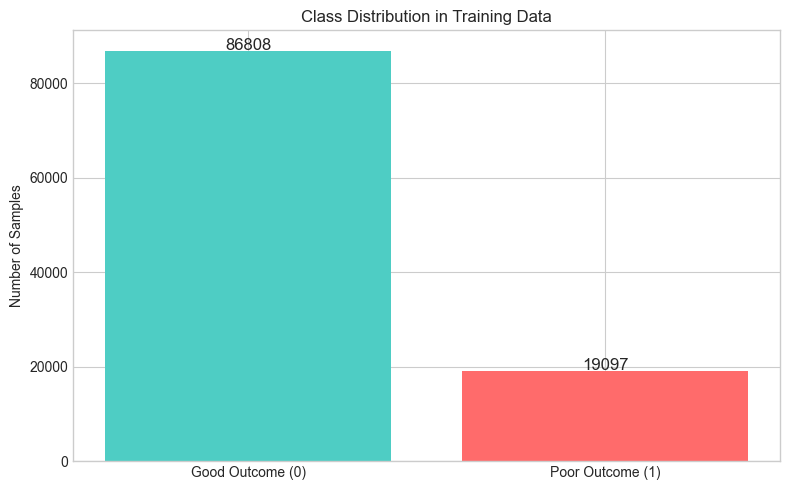

In [5]:
# Count class distribution
unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("Class Distribution in Training Set:")
print("=" * 40)
for cls, count in class_distribution.items():
    percentage = count / len(y_train) * 100
    label = "Poor Outcome" if cls == 1 else "Good Outcome"
    print(f"Class {cls} ({label}): {count} samples ({percentage:.1f}%)")

# Calculate imbalance ratio
majority_class = max(counts)
minority_class = min(counts)
imbalance_ratio = majority_class / minority_class
print(f"\nImbalance Ratio: {imbalance_ratio:.2f}:1")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Good Outcome (0)', 'Poor Outcome (1)'], counts, color=['#4ecdc4', '#ff6b6b'])
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution in Training Data')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            f'{count}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

## Step 4: Define Random Forest Model

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
print('Random Forest pipeline defined!')

Random Forest pipeline defined!


## Step 5: Cross-Validation

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

print('Running cross-validation for Random Forest...')
print('=' * 60)

cv_results = cross_validate(
    rf_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=1
)

for m in ['precision', 'recall', 'f1', 'roc_auc']:
    train_m = cv_results[f'train_{m}'].mean()
    val_m = cv_results[f'test_{m}'].mean()
    print(f'  {m:12s}: train={train_m:.3f}, val={val_m:.3f}, gap={train_m-val_m:.3f}')

Running cross-validation for Random Forest...
  precision   : train=0.379, val=0.323, gap=0.056
  recall      : train=0.564, val=0.483, gap=0.081
  f1          : train=0.453, val=0.387, gap=0.066
  roc_auc     : train=0.747, val=0.686, gap=0.061


## Step 6: Overfitting Analysis - Learning Curves

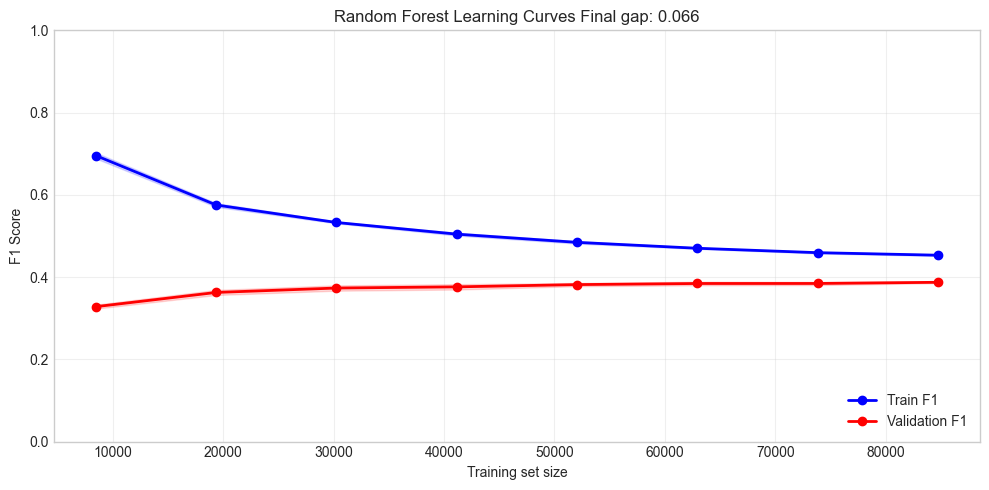

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

train_sizes_abs, train_scores, val_scores = learning_curve(
    rf_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

ax.fill_between(train_sizes_abs, train_mean-train_scores.std(1), train_mean+train_scores.std(1), alpha=0.15, color='blue')
ax.fill_between(train_sizes_abs, val_mean-val_scores.std(1), val_mean+val_scores.std(1), alpha=0.15, color='red')
ax.plot(train_sizes_abs, train_mean, 'o-', color='blue', linewidth=2, label='Train F1')
ax.plot(train_sizes_abs, val_mean, 'o-', color='red', linewidth=2, label='Validation F1')
ax.set_title(f'Random Forest Learning Curves Final gap: {train_mean[-1]-val_mean[-1]:.3f}')
ax.set_xlabel('Training set size'); ax.set_ylabel('F1 Score')
ax.legend(loc='lower right'); ax.set_ylim(0, 1); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Step 7: Train Initial RF on Full Training Data

Training initial Random Forest...
Done!


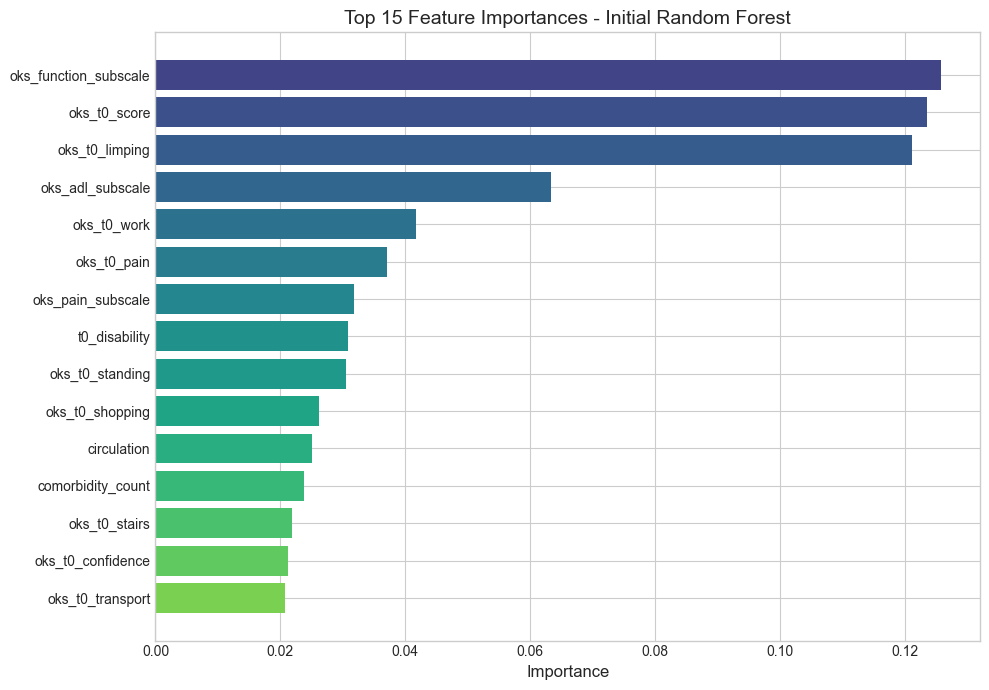

In [10]:
print('Training initial Random Forest...')
rf_pipeline.fit(X_train, y_train)
rf_initial_model = rf_pipeline
print('Done!')

rf_init = rf_initial_model.named_steps['model']
imp_init_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_init.feature_importances_}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_15 = imp_init_df.head(15)
ax.barh(top_15['Feature'], top_15['Importance'], color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_15))))
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 15 Feature Importances - Initial Random Forest', fontsize=14)
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## Step 15: Random Forest Hyperparameter Tuning

### What is Hyperparameter Tuning?

**Hyperparameters** are settings you choose BEFORE training a model (unlike regular parameters that the model learns from data).

Think of it like baking a cake:
- **Parameters** = The exact amounts the recipe figures out (learned during training)
- **Hyperparameters** = Oven temperature, baking time (YOU decide these before starting)

### Key Random Forest Hyperparameters Explained:

| Hyperparameter | What it does | Effect |
|----------------|--------------|--------|
| `n_estimators` | Number of trees in the forest | More trees = more stable predictions, but slower |
| `max_depth` | How deep each tree can grow | Deeper = can learn complex patterns, but may overfit |
| `min_samples_split` | Minimum samples needed to split a node | Higher = simpler trees, less overfitting |
| `min_samples_leaf` | Minimum samples in each leaf | Higher = smoother predictions |
| `max_features` | Features to consider at each split | Lower = more diversity between trees |
| `class_weight` | How to handle imbalanced classes | 'balanced' gives more weight to minority class |

### Our Strategy:
1. Try many combinations of hyperparameters
2. For each combination, check if we can achieve 80% precision
3. Among those that achieve 80% precision, pick the one with highest recall

In [11]:
# Step 15a: Set Up Hyperparameter Grid for Random Forest
# ======================================================
# We'll try different combinations to find the best one

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the hyperparameter grid
# Each key is a hyperparameter, and the values are options to try
param_grid = {
    'model__n_estimators': [100, 200, 300],           # Number of trees
    'model__max_depth': [5, 10, 15, 20, None],        # None = unlimited depth
    'model__min_samples_split': [2, 5, 10, 20],       # Min samples to split
    'model__min_samples_leaf': [1, 2, 4, 8],          # Min samples per leaf
    'model__max_features': ['sqrt', 'log2', 0.3],     # Features per split
    'model__class_weight': ['balanced', 'balanced_subsample']  # Handle imbalance
}

# Calculate total combinations
total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)

print("Hyperparameter Tuning Setup")
print("=" * 50)
print(f"\nTotal possible combinations: {total_combinations}")
print("\nHyperparameter options:")
for param, values in param_grid.items():
    param_name = param.replace('model__', '')
    print(f"  {param_name}: {values}")

Hyperparameter Tuning Setup

Total possible combinations: 1440

Hyperparameter options:
  n_estimators: [100, 200, 300]
  max_depth: [5, 10, 15, 20, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 4, 8]
  max_features: ['sqrt', 'log2', 0.3]
  class_weight: ['balanced', 'balanced_subsample']


In [12]:
# Step 15b: Run Hyperparameter Tuning
# ====================================
# We use RandomizedSearchCV to try a subset of combinations (faster than trying all)
# We optimize for 'recall' because precision can be controlled via threshold later

from sklearn.model_selection import RandomizedSearchCV

# Create the base Random Forest pipeline
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Set up RandomizedSearchCV
# - n_iter=50: Try 50 random combinations (instead of all 960)
# - scoring='recall': Optimize for recall (we'll handle precision via threshold)
# - cv=5: 5-fold cross-validation
# - refit=True: Train the best model on full training data

print("Starting Hyperparameter Tuning...")
print("This may take a few minutes...\n")

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=50,                    # Number of random combinations to try
    scoring='precision',             # Optimize for precision
    cv=5,                         # 5-fold cross-validation
    random_state=42,
    n_jobs=-1,                    # Use all CPU cores
    verbose=1,                    # Show progress
    refit=True                    # Refit best model on full training data
)

# Run the search
random_search.fit(X_train, y_train)

print("\n" + "=" * 50)
print("Hyperparameter tuning complete!")

Starting Hyperparameter Tuning...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Hyperparameter tuning complete!


In [13]:
# Step 15c: View Best Hyperparameters
# ====================================
# Let's see which combination performed best

print("Best Hyperparameters Found:")
print("=" * 50)

# Get the best parameters and clean up the names for readability
best_params = random_search.best_params_
for param, value in best_params.items():
    clean_name = param.replace('model__', '')
    print(f"  {clean_name}: {value}")

print(f"\nBest Cross-Validation Precision: {random_search.best_score_:.3f}")

# Store the best model
best_rf_model = random_search.best_estimator_

print("\n" + "=" * 50)
print("Best model saved as 'best_rf_model'")

Best Hyperparameters Found:
  n_estimators: 200
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: log2
  max_depth: None
  class_weight: balanced

Best Cross-Validation Precision: 0.579

Best model saved as 'best_rf_model'


## Step 9: Evaluate Tuned RF at Default Threshold (0.5)

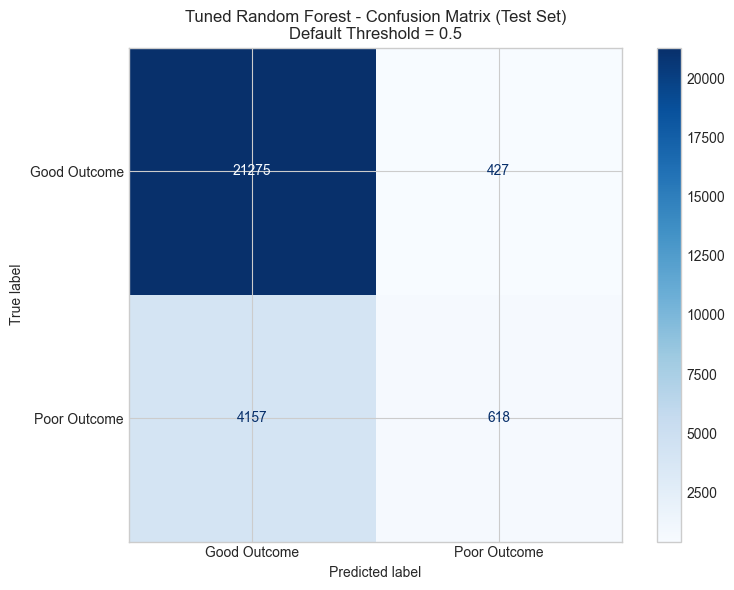


Confusion Matrix Interpretation (Threshold = 0.5):
--------------------------------------------------
True Negatives (Good predicted Good):   21,275
False Positives (Good predicted Poor):  427
False Negatives (Poor predicted Good):  4,157
True Positives (Poor predicted Poor):   618

Accuracy: 82.7%
Precision: 59.1% of patients predicted as Poor actually had Poor outcomes
Recall: 12.9% of actual Poor outcomes were correctly identified


In [14]:
# Step 15c-ii: Confusion Matrix for Tuned Random Forest (Default Threshold 0.5)
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 6))

# Get predictions with default threshold (0.5)
y_proba_tuned_15c = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba_tuned_15c >= 0.5).astype(int)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Outcome', 'Poor Outcome'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Tuned Random Forest - Confusion Matrix (Test Set)\nDefault Threshold = 0.5', fontsize=12)

plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Interpretation (Threshold = 0.5):")
print("-" * 50)
print(f"True Negatives (Good predicted Good):   {tn:,}")
print(f"False Positives (Good predicted Poor):  {fp:,}")
print(f"False Negatives (Poor predicted Good):  {fn:,}")
print(f"True Positives (Poor predicted Poor):   {tp:,}")
print()
total = tn + fp + fn + tp
print(f"Accuracy: {(tn + tp) / total * 100:.1f}%")
print(f"Precision: {tp/(tp+fp)*100:.1f}% of patients predicted as Poor actually had Poor outcomes")
print(f"Recall: {tp/(tp+fn)*100:.1f}% of actual Poor outcomes were correctly identified")


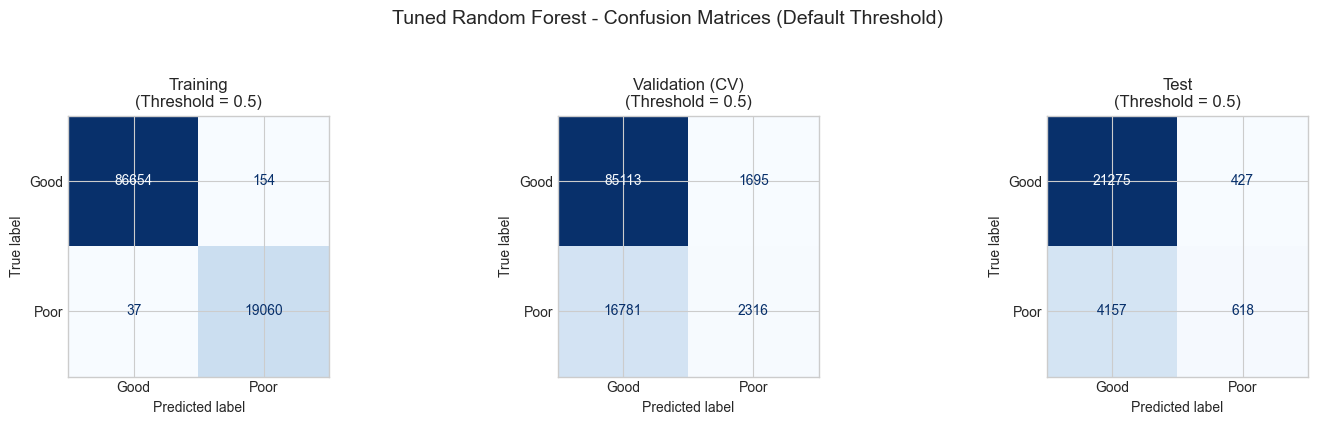


Confusion Matrix Summary (Threshold = 0.5):

Training:
  True Negatives (Good predicted Good):   86,654
  False Positives (Good predicted Poor):  154
  False Negatives (Poor predicted Good):  37
  True Positives (Poor predicted Poor):   19,060
  ---
  Accuracy:  99.8%
  Precision: 99.2%
  Recall:    99.8%

Validation (CV):
  True Negatives (Good predicted Good):   85,113
  False Positives (Good predicted Poor):  1,695
  False Negatives (Poor predicted Good):  16,781
  True Positives (Poor predicted Poor):   2,316
  ---
  Accuracy:  82.6%
  Precision: 57.7%
  Recall:    12.1%

Test:
  True Negatives (Good predicted Good):   21,275
  False Positives (Good predicted Poor):  427
  False Negatives (Poor predicted Good):  4,157
  True Positives (Poor predicted Poor):   618
  ---
  Accuracy:  82.7%
  Precision: 59.1%
  Recall:    12.9%


In [15]:
# Step 15c-iii: Confusion Matrices for Training, Validation & Test (Default Threshold 0.5)
# =========================================================================================

from sklearn.model_selection import cross_val_predict

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Get predictions for all datasets at threshold 0.5
# Training set
y_train_proba_15c = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred_15c = (y_train_proba_15c >= 0.5).astype(int)

# Validation set (out-of-fold via 5-fold CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba_15c = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]
y_val_pred_15c = (y_val_proba_15c >= 0.5).astype(int)

# Test set
y_test_proba_15c = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_15c = (y_test_proba_15c >= 0.5).astype(int)

datasets = {
    'Training': (y_train, y_train_pred_15c),
    'Validation (CV)': (y_train, y_val_pred_15c),
    'Test': (y_test, y_test_pred_15c)
}

for ax, (title, (y_true, y_pred)) in zip(axes, datasets.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Poor'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n(Threshold = 0.5)')

plt.suptitle('Tuned Random Forest - Confusion Matrices (Default Threshold)', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Print summary for all datasets
print("\nConfusion Matrix Summary (Threshold = 0.5):")
print("=" * 60)

for title, (y_true, y_pred) in datasets.items():
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = tn + fp + fn + tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\n{title}:")
    print(f"  True Negatives (Good predicted Good):   {tn:,}")
    print(f"  False Positives (Good predicted Poor):  {fp:,}")
    print(f"  False Negatives (Poor predicted Good):  {fn:,}")
    print(f"  True Positives (Poor predicted Poor):   {tp:,}")
    print(f"  ---")
    print(f"  Accuracy:  {(tn + tp) / total * 100:.1f}%")
    print(f"  Precision: {precision * 100:.1f}%")
    print(f"  Recall:    {recall * 100:.1f}%")


## Step 10: Find Optimal Threshold for 80% Precision

In [16]:
# Step 15d: Find Optimal Threshold for 80% Precision
# ===================================================
# Now we find the threshold that gives us 80% precision with highest recall

from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities on test set
y_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_tuned)

# Find threshold where precision >= 0.80
target_precision = 0.80
valid_indices = np.where(precisions >= target_precision)[0]

if len(valid_indices) > 0:
    # Get the index with highest recall among valid precisions
    best_idx = valid_indices[0]
    
    # Handle edge case
    if best_idx >= len(thresholds):
        best_idx = len(thresholds) - 1
    
    optimal_threshold_tuned = thresholds[best_idx]
    achieved_precision_tuned = precisions[best_idx]
    achieved_recall_tuned = recalls[best_idx]
    
    print("Tuned Random Forest - Optimal Threshold for 80% Precision")
    print("=" * 60)
    print(f"\nOptimal threshold: {optimal_threshold_tuned:.3f}")
    print(f"Precision achieved: {achieved_precision_tuned:.3f}")
    print(f"Recall achieved: {achieved_recall_tuned:.3f}")
else:
    print("Warning: Cannot achieve 80% precision with this model")
    optimal_threshold_tuned = 0.5
    achieved_recall_tuned = 0

print("\n" + "=" * 60)

Tuned Random Forest - Optimal Threshold for 80% Precision

Optimal threshold: 0.658
Precision achieved: 0.800
Recall achieved: 0.061



## Step 11: Compare Initial vs Tuned RF

In [17]:
# Step 15e: Compare Original vs Tuned Random Forest
# ==================================================
# Let's see how much improvement we achieved

# Original Random Forest results (from earlier)
original_rf = rf_initial_model
y_proba_original = original_rf.predict_proba(X_test)[:, 1]

# Find original threshold for 80% precision
prec_orig, rec_orig, thresh_orig = precision_recall_curve(y_test, y_proba_original)
valid_orig = np.where(prec_orig >= 0.80)[0]
if len(valid_orig) > 0:
    idx_orig = valid_orig[0]
    if idx_orig >= len(thresh_orig):
        idx_orig = len(thresh_orig) - 1
    original_threshold = thresh_orig[idx_orig]
    original_precision = prec_orig[idx_orig]
    original_recall = rec_orig[idx_orig]
else:
    original_threshold, original_precision, original_recall = 0.5, 0, 0

# Create comparison table
comparison_data = {
    'Model': ['Original Random Forest', 'Tuned Random Forest'],
    'Threshold': [original_threshold, optimal_threshold_tuned],
    'Precision': [original_precision, achieved_precision_tuned],
    'Recall': [original_recall, achieved_recall_tuned]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Precision Improvement'] = ''
if original_precision > 0:
    improvement = ((achieved_precision_tuned - original_precision) / original_precision) * 100
    comparison_df.loc[1, 'Precision Improvement'] = f"+{improvement:.1f}%"

print("Comparison: Original vs Tuned Random Forest (at 80% Precision)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)

# Interpret the results
print("\nInterpretation:")
print("-" * 40)
if achieved_precision_tuned > original_precision:
    print(f"The tuned model finds {achieved_recall_tuned:.1%} of good outcomes")
    print(f"compared to {original_recall:.1%} with the original model.")
    print(f"\nThis is a {improvement:.1f}% relative improvement in recall!")
else:
    print("The tuning did not improve recall at 80% precision.")
    print("This suggests the data may have limited separability.")

Comparison: Original vs Tuned Random Forest (at 80% Precision)
                 Model  Threshold  Precision   Recall Precision Improvement
Original Random Forest   0.811012   0.800505 0.066387                      
   Tuned Random Forest   0.658026   0.800000 0.061152                +-0.1%


Interpretation:
----------------------------------------
The tuning did not improve recall at 80% precision.
This suggests the data may have limited separability.


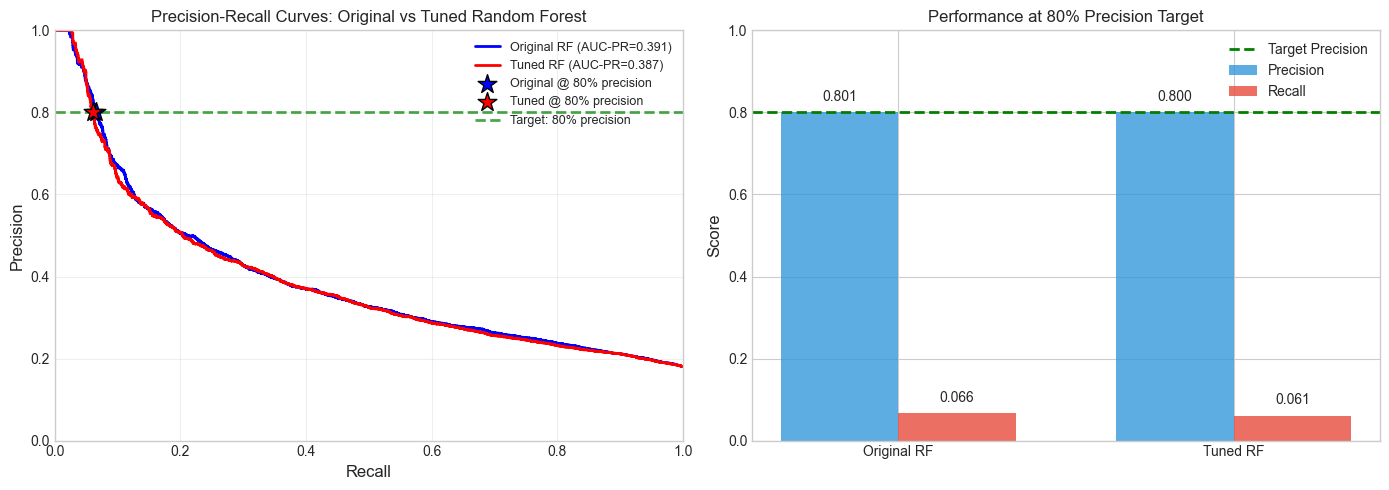

In [18]:
# Step 15f: Visualize PR Curves - Original vs Tuned
# =================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: Precision-Recall Curves ---
ax = axes[0]

# Original RF curve
prec_orig, rec_orig, _ = precision_recall_curve(y_test, y_proba_original)
auc_orig = average_precision_score(y_test, y_proba_original)
ax.plot(rec_orig, prec_orig, 'b-', linewidth=2, label=f'Original RF (AUC-PR={auc_orig:.3f})')

# Tuned RF curve
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)
auc_tuned = average_precision_score(y_test, y_proba_tuned)
ax.plot(rec_tuned, prec_tuned, 'r-', linewidth=2, label=f'Tuned RF (AUC-PR={auc_tuned:.3f})')

# Mark operating points at 80% precision
ax.scatter([original_recall], [original_precision], c='blue', s=200, marker='*', 
           edgecolors='black', zorder=5, label='Original @ 80% precision')
ax.scatter([achieved_recall_tuned], [achieved_precision_tuned], c='red', s=200, marker='*', 
           edgecolors='black', zorder=5, label='Tuned @ 80% precision')

# 80% precision line
ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Target: 80% precision')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves: Original vs Tuned Random Forest', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# --- Right plot: Bar comparison ---
ax = axes[1]

rf_comparison_labels = ['Original RF', 'Tuned RF']
recalls = [original_recall, achieved_recall_tuned]
precisions = [original_precision, achieved_precision_tuned]

x = np.arange(len(rf_comparison_labels))
width = 0.35

bars1 = ax.bar(x - width/2, precisions, width, label='Precision', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, recalls, width, label='Recall', color='#e74c3c', alpha=0.8)

ax.axhline(y=0.80, color='green', linestyle='--', linewidth=2, label='Target Precision')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance at 80% Precision Target', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(rf_comparison_labels)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Step 12: Full Evaluation at 80% Precision Threshold

Tuned Random Forest - Full Evaluation at 80% Precision

Using threshold: 0.658

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

Good Outcome       0.83      1.00      0.90     21702
Poor Outcome       0.80      0.06      0.11      4775

    accuracy                           0.83     26477
   macro avg       0.81      0.53      0.51     26477
weighted avg       0.82      0.83      0.76     26477



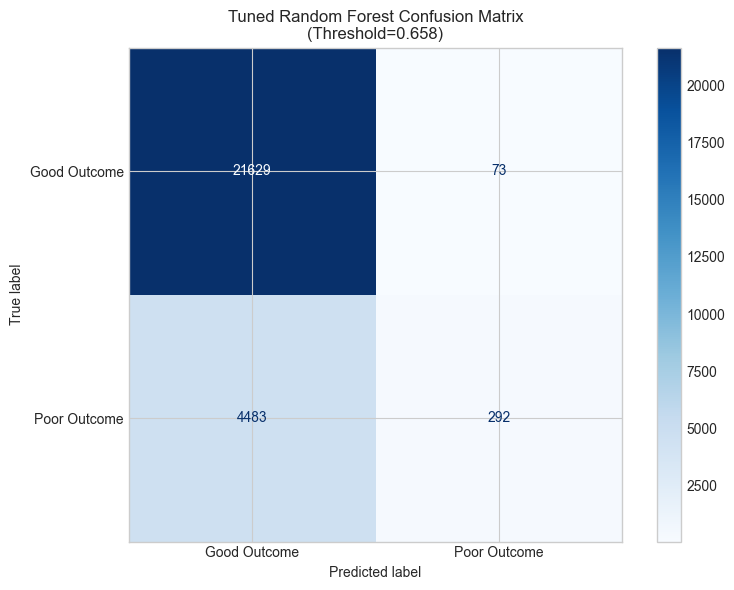


Confusion Matrix Interpretation:
----------------------------------------
True Negatives (correctly predicted Good):  21629
False Positives (incorrectly predicted Poor): 73
False Negatives (missed Poor outcomes):     4483
True Positives (correctly predicted Poor):  292

Of 365 patients predicted to have Poor outcomes,
292 (80.0%) actually had Poor outcomes (this is Precision)


In [19]:
# Step 15g: Full Evaluation of Tuned Model at 80% Precision
# ==========================================================

# Make predictions with optimal threshold
y_pred_tuned = (y_proba_tuned >= optimal_threshold_tuned).astype(int)

print("Tuned Random Forest - Full Evaluation at 80% Precision")
print("=" * 60)
print(f"\nUsing threshold: {optimal_threshold_tuned:.3f}")
print("\nClassification Report:")
print("-" * 40)
print(classification_report(y_test, y_pred_tuned, target_names=['Good Outcome', 'Poor Outcome']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good Outcome', 'Poor Outcome'])
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Tuned Random Forest Confusion Matrix\n(Threshold={optimal_threshold_tuned:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

# Explain the confusion matrix
print("\nConfusion Matrix Interpretation:")
print("-" * 40)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Good):  {tn}")
print(f"False Positives (incorrectly predicted Poor): {fp}")
print(f"False Negatives (missed Poor outcomes):     {fn}")
print(f"True Positives (correctly predicted Poor):  {tp}")
print(f"\nOf {tp + fp} patients predicted to have Poor outcomes,")
print(f"{tp} ({tp/(tp+fp)*100:.1f}%) actually had Poor outcomes (this is Precision)")

## Step 13: Feature Importances - Tuned RF

Top 20 Most Important Features (Tuned Random Forest)
              Feature  Importance
         oks_t0_score    0.069626
oks_function_subscale    0.062531
     oks_adl_subscale    0.048803
       oks_t0_limping    0.038274
    comorbidity_count    0.033591
       oks_t0_walking    0.032295
    oks_t0_confidence    0.032170
    oks_pain_subscale    0.031243
    t0_symptom_period    0.030536
      oks_t0_shopping    0.029985
       oks_t0_washing    0.027022
        oks_t0_stairs    0.026728
    oks_t0_night_pain    0.025739
          oks_t0_work    0.025626
      oks_t0_kneeling    0.025406
      oks_t0_standing    0.024864
     oks_t0_transport    0.024670
          oks_t0_pain    0.018954
           t0_anxiety    0.017839
               gender    0.016025


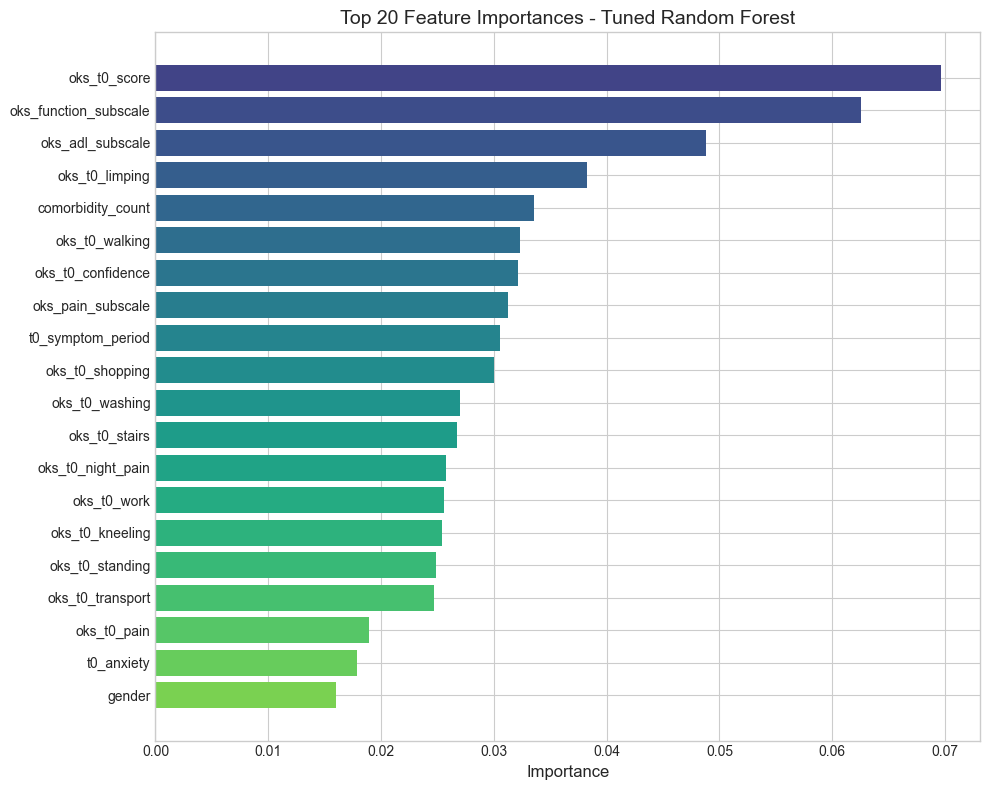

In [20]:
# Step 15h: Feature Importances from Tuned Random Forest
# =======================================================
# Let's see which features the tuned model considers most important

# Get feature importances from the tuned model
rf_model = best_rf_model.named_steps['model']
feature_importances = rf_model.feature_importances_

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (Tuned Random Forest)")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))

# Visualize top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['Feature'], top_20['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Feature Importances - Tuned Random Forest', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Step 16: Evaluate Best Random Forest on Training, Validation & Test Sets

**What's happening here:**
- We evaluate the tuned Random Forest model on three datasets:
  - **Training set**: How well the model fits the data it was trained on (overfitting check)
  - **Validation set**: Out-of-fold predictions via 5-fold cross-validation (honest estimate during development)
  - **Test set**: Final held-out evaluation (unbiased estimate of real-world performance)
- We use the optimized threshold for 80% precision found in Step 15d
- Metrics reported: Precision, Recall, F1-Score, ROC-AUC, PR-AUC, and True Negatives

In [21]:
# Step 16: Evaluate Tuned Random Forest on Train, Validation & Test
# ==================================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# Use the threshold optimized for 80% precision (from Step 15d)
threshold = optimal_threshold_tuned

print("Step 16: Tuned Random Forest - Train / Validation / Test Evaluation")
print("=" * 70)
print(f"Model: Tuned Random Forest (best from RandomizedSearchCV)")
print(f"Threshold used: {threshold:.3f}")
print()

# --- 1. Training Set (in-sample) ---
y_train_proba = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= threshold).astype(int)

# --- 2. Validation Set (out-of-fold via 5-fold CV) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]
y_val_pred = (y_val_proba >= threshold).astype(int)

# --- 3. Test Set (held-out) ---
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= threshold).astype(int)

# --- Calculate metrics ---
def calc_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'True Negatives': int(tn)
    }

results = {
    'Training':       calc_metrics(y_train, y_train_pred, y_train_proba),
    'Validation (CV)': calc_metrics(y_train, y_val_pred, y_val_proba),
    'Test':           calc_metrics(y_test, y_test_pred, y_test_proba),
}

# --- Build results table ---
results_df = pd.DataFrame(results).T
# Round numeric columns, keep True Negatives as int
numeric_cols = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
results_df[numeric_cols] = results_df[numeric_cols].round(3)
results_df['True Negatives'] = results_df['True Negatives'].astype(int)

print(f"Results at threshold = {threshold:.3f}")
print("-" * 70)
print(results_df.to_string())
print()

# --- Overfitting check ---
train_recall = results_df.loc['Training', 'Recall']
val_recall = results_df.loc['Validation (CV)', 'Recall']
test_recall = results_df.loc['Test', 'Recall']

print("Overfitting check (Train vs Validation gap):")
print(f"  Recall gap:  {train_recall - val_recall:.3f}")
print(f"  ROC-AUC gap: {results_df.loc['Training', 'ROC-AUC'] - results_df.loc['Validation (CV)', 'ROC-AUC']:.3f}")
print(f"  PR-AUC gap:  {results_df.loc['Training', 'PR-AUC'] - results_df.loc['Validation (CV)', 'PR-AUC']:.3f}")

Step 16: Tuned Random Forest - Train / Validation / Test Evaluation
Model: Tuned Random Forest (best from RandomizedSearchCV)
Threshold used: 0.658

Results at threshold = 0.658
----------------------------------------------------------------------
                 Precision  Recall  F1-Score  ROC-AUC  PR-AUC  True Negatives
Training             0.998   0.549     0.709    1.000   0.999           86792
Validation (CV)      0.766   0.055     0.103    0.681   0.371           86486
Test                 0.799   0.061     0.113    0.691   0.387           21629

Overfitting check (Train vs Validation gap):
  Recall gap:  0.494
  ROC-AUC gap: 0.319
  PR-AUC gap:  0.628


## Step 17: Evaluate Best Random Forest with Threshold = 0.8

Same evaluation as Step 16, but using a fixed threshold of 0.8 instead of the optimized threshold.

In [22]:
# Step 17: Evaluate Tuned Random Forest with Threshold = 0.8
# ===========================================================

threshold_fixed = 0.8

print("Step 17: Tuned Random Forest - Train / Validation / Test Evaluation")
print("=" * 70)
print(f"Model: Tuned Random Forest (best from RandomizedSearchCV)")
print(f"Threshold used: {threshold_fixed}")
print()

# --- 1. Training Set (in-sample) ---
y_train_proba = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred = (y_train_proba >= threshold_fixed).astype(int)

# --- 2. Validation Set (out-of-fold via 5-fold CV) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv, method='predict_proba'
)[:, 1]
y_val_pred = (y_val_proba >= threshold_fixed).astype(int)

# --- 3. Test Set (held-out) ---
y_test_proba = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= threshold_fixed).astype(int)

# --- Calculate metrics ---
def calc_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'True Negatives': int(tn)
    }

results_17 = {
    'Training':       calc_metrics(y_train, y_train_pred, y_train_proba),
    'Validation (CV)': calc_metrics(y_train, y_val_pred, y_val_proba),
    'Test':           calc_metrics(y_test, y_test_pred, y_test_proba),
}

# --- Build results table ---
results_17_df = pd.DataFrame(results_17).T
numeric_cols = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
results_17_df[numeric_cols] = results_17_df[numeric_cols].round(3)
results_17_df['True Negatives'] = results_17_df['True Negatives'].astype(int)

print(f"Results at threshold = {threshold_fixed}")
print("-" * 70)
print(results_17_df.to_string())
print()

# --- Overfitting check ---
print("Overfitting check (Train vs Validation gap):")
print(f"  Recall gap:  {results_17_df.loc['Training', 'Recall'] - results_17_df.loc['Validation (CV)', 'Recall']:.3f}")
print(f"  ROC-AUC gap: {results_17_df.loc['Training', 'ROC-AUC'] - results_17_df.loc['Validation (CV)', 'ROC-AUC']:.3f}")
print(f"  PR-AUC gap:  {results_17_df.loc['Training', 'PR-AUC'] - results_17_df.loc['Validation (CV)', 'PR-AUC']:.3f}")

Step 17: Tuned Random Forest - Train / Validation / Test Evaluation
Model: Tuned Random Forest (best from RandomizedSearchCV)
Threshold used: 0.8

Results at threshold = 0.8
----------------------------------------------------------------------
                 Precision  Recall  F1-Score  ROC-AUC  PR-AUC  True Negatives
Training             1.000   0.090     0.166    1.000   0.999           86808
Validation (CV)      0.920   0.029     0.056    0.681   0.371           86760
Test                 0.969   0.033     0.064    0.691   0.387           21697

Overfitting check (Train vs Validation gap):
  Recall gap:  0.061
  ROC-AUC gap: 0.319
  PR-AUC gap:  0.628


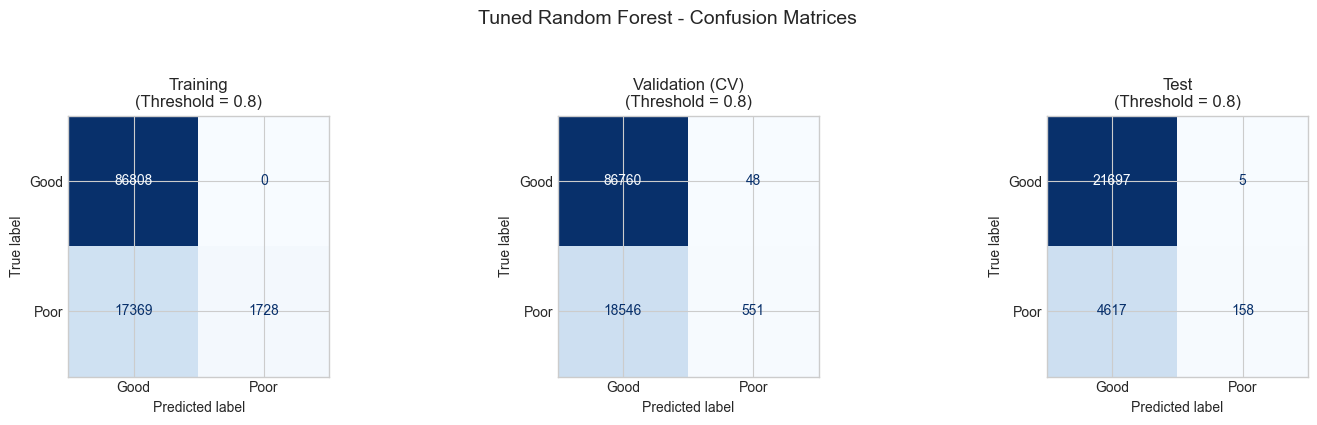


Confusion Matrix Summary (Threshold = 0.8):
--------------------------------------------------

Training:
  True Negatives (Good predicted Good):   86,808
  False Positives (Good predicted Poor):  0
  False Negatives (Poor predicted Good):  17,369
  True Positives (Poor predicted Poor):   1,728

Validation (CV):
  True Negatives (Good predicted Good):   86,760
  False Positives (Good predicted Poor):  48
  False Negatives (Poor predicted Good):  18,546
  True Positives (Poor predicted Poor):   551

Test:
  True Negatives (Good predicted Good):   21,697
  False Positives (Good predicted Poor):  5
  False Negatives (Poor predicted Good):  4,617
  True Positives (Poor predicted Poor):   158


In [23]:
# Step 17b: Confusion Matrix Visualization
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = {
    'Training': (y_train, (y_train_proba >= threshold_fixed).astype(int)),
    'Validation (CV)': (y_train, (y_val_proba >= threshold_fixed).astype(int)),
    'Test': (y_test, (y_test_proba >= threshold_fixed).astype(int))
}

for ax, (title, (y_true, y_pred)) in zip(axes, datasets.items()):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good', 'Poor'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n(Threshold = {threshold_fixed})')

plt.suptitle('Tuned Random Forest - Confusion Matrices', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Print summary
print("\nConfusion Matrix Summary (Threshold = 0.8):")
print("-" * 50)
for title, (y_true, y_pred) in datasets.items():
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{title}:")
    print(f"  True Negatives (Good predicted Good):   {tn:,}")
    print(f"  False Positives (Good predicted Poor):  {fp:,}")
    print(f"  False Negatives (Poor predicted Good):  {fn:,}")
    print(f"  True Positives (Poor predicted Poor):   {tp:,}")

## Step 15: Threshold Comparison Table

In [24]:
# Step 18: Threshold Comparison Table for Tuned Random Forest
# ============================================================

thresholds = [0.5, 0.6, 0.7, 0.8]

# Get predicted probabilities on test set
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1': f1_score(y_test, y_pred_t, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Positive Predictions': int(tp + fp),
    })

threshold_df = pd.DataFrame(threshold_results).set_index('Threshold')
threshold_df[['Precision', 'Recall', 'F1', 'Specificity']] = threshold_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
threshold_df['Positive Predictions'] = threshold_df['Positive Predictions'].astype(int)

print("Tuned Random Forest - Performance at Different Thresholds (Test Set)")
print("=" * 75)
print(threshold_df.to_string())
print("\n" + "=" * 75)
print(f"\nTotal test samples: {len(y_test):,}")
print(f"Actual positive cases (Poor Outcome): {y_test.sum():,}")

Tuned Random Forest - Performance at Different Thresholds (Test Set)
           Precision  Recall     F1  Specificity  Positive Predictions
Threshold                                                             
0.5            0.591   0.129  0.212        0.980                  1045
0.6            0.715   0.080  0.145        0.993                   537
0.7            0.855   0.052  0.098        0.998                   290
0.8            0.969   0.033  0.064        1.000                   163


Total test samples: 26,477
Actual positive cases (Poor Outcome): 4,775


In [45]:
import joblib


joblib.dump(best_rf_model, 'best_rf_model_yvonne.joblib')

['best_rf_model_yvonne.joblib']

## Step 16: Top 20 Feature Importances

Top 20 Most Important Features (Tuned Random Forest)
              Feature  Importance
         oks_t0_score    0.069626
oks_function_subscale    0.062531
     oks_adl_subscale    0.048803
       oks_t0_limping    0.038274
    comorbidity_count    0.033591
       oks_t0_walking    0.032295
    oks_t0_confidence    0.032170
    oks_pain_subscale    0.031243
    t0_symptom_period    0.030536
      oks_t0_shopping    0.029985
       oks_t0_washing    0.027022
        oks_t0_stairs    0.026728
    oks_t0_night_pain    0.025739
          oks_t0_work    0.025626
      oks_t0_kneeling    0.025406
      oks_t0_standing    0.024864
     oks_t0_transport    0.024670
          oks_t0_pain    0.018954
           t0_anxiety    0.017839
               gender    0.016025


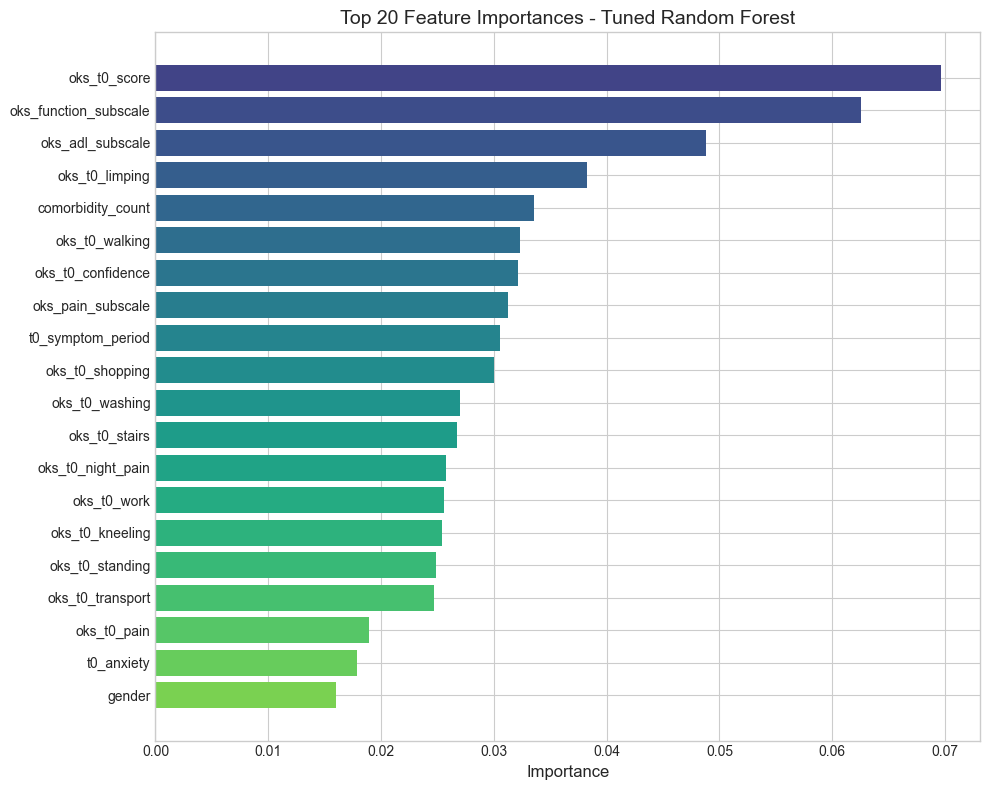

In [25]:
# Step 19: Top 20 Feature Importances - Tuned Random Forest
# ===========================================================

rf_model_final = best_rf_model.named_steps['model']
importances = rf_model_final.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Print table
print("Top 20 Most Important Features (Tuned Random Forest)")
print("=" * 55)
print(importance_df.head(20).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = importance_df.head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_20)))
ax.barh(top_20['Feature'], top_20['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Top 20 Feature Importances - Tuned Random Forest', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Feature Importance Coverage
Total features:          57
Top 20 features explain: 0.642 / 1.000 = 64.2%
Remaining 37 features:   0.358 / 1.000 = 35.8%

Cumulative importance by feature rank:
--------------------------------------------------
  Top  1:   7.0%  ███  (oks_t0_score)
  Top  2:  13.2%  ██████  (oks_function_subscale)
  Top  3:  18.1%  █████████  (oks_adl_subscale)
  Top  4:  21.9%  ██████████  (oks_t0_limping)
  Top  5:  25.3%  ████████████  (comorbidity_count)
  Top  6:  28.5%  ██████████████  (oks_t0_walking)
  Top  7:  31.7%  ███████████████  (oks_t0_confidence)
  Top  8:  34.9%  █████████████████  (oks_pain_subscale)
  Top  9:  37.9%  ██████████████████  (t0_symptom_period)
  Top 10:  40.9%  ████████████████████  (oks_t0_shopping)
  Top 11:  43.6%  █████████████████████  (oks_t0_washing)
  Top 12:  46.3%  ███████████████████████  (oks_t0_stairs)
  Top 13:  48.9%  ████████████████████████  (oks_t0_night_pain)
  Top 14:  51.4%  █████████████████████████  (oks_t0_work)
  Top

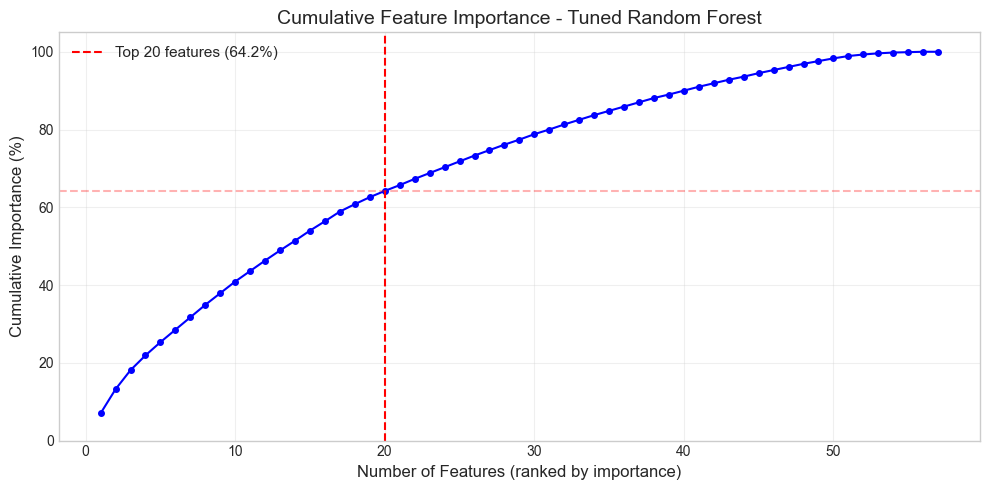

In [26]:
# Step 19b: How much do the top 20 features explain?
# ====================================================

total_importance = importance_df['Importance'].sum()
top_20_importance = importance_df.head(20)['Importance'].sum()
remaining_importance = total_importance - top_20_importance

print("Feature Importance Coverage")
print("=" * 50)
print(f"Total features:          {len(importance_df)}")
print(f"Top 20 features explain: {top_20_importance:.3f} / {total_importance:.3f} = {top_20_importance/total_importance*100:.1f}%")
print(f"Remaining {len(importance_df)-20} features:   {remaining_importance:.3f} / {total_importance:.3f} = {remaining_importance/total_importance*100:.1f}%")

# Show cumulative importance
importance_df_sorted = importance_df.reset_index(drop=True)
importance_df_sorted['Cumulative'] = importance_df_sorted['Importance'].cumsum()
importance_df_sorted['Cumulative %'] = (importance_df_sorted['Cumulative'] / total_importance * 100).round(1)

print(f"\nCumulative importance by feature rank:")
print("-" * 50)
for i, row in importance_df_sorted.head(20).iterrows():
    bar = "█" * int(row['Cumulative %'] / 2)
    print(f"  Top {i+1:2d}: {row['Cumulative %']:5.1f}%  {bar}  ({row['Feature']})")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(importance_df_sorted)+1), importance_df_sorted['Cumulative %'], 'b-o', markersize=4)
ax.axvline(x=20, color='red', linestyle='--', label=f'Top 20 features ({top_20_importance/total_importance*100:.1f}%)')
ax.axhline(y=top_20_importance/total_importance*100, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Number of Features (ranked by importance)', fontsize=12)
ax.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax.set_title('Cumulative Feature Importance - Tuned Random Forest', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 17: Summary Tables

In [27]:
# Step 20: Train / Validation / Test Summary Table - Tuned Random Forest
# ========================================================================

from sklearn.model_selection import cross_val_predict

# Default threshold
threshold_rf = 0.5

# --- Training set ---
y_train_proba_rf = best_rf_model.predict_proba(X_train)[:, 1]
y_train_pred_rf = (y_train_proba_rf >= threshold_rf).astype(int)

# --- Validation set (out-of-fold via 5-fold CV) ---
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_val_proba_rf = cross_val_predict(
    best_rf_model, X_train, y_train, cv=cv_rf, method='predict_proba'
)[:, 1]
y_val_pred_rf = (y_val_proba_rf >= threshold_rf).astype(int)

# --- Test set ---
y_test_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]
y_test_pred_rf = (y_test_proba_rf >= threshold_rf).astype(int)

# --- Calculate metrics ---
def calc_full_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total = len(y_true)
    predicted_pos = int(tp + fp)
    return {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Predicted Pos (%)': predicted_pos / total * 100,
        'Predicted Pos (#)': predicted_pos,
    }

results_20 = {
    'Training':        calc_full_metrics(y_train, y_train_pred_rf),
    'Validation (CV)': calc_full_metrics(y_train, y_val_pred_rf),
    'Test':            calc_full_metrics(y_test, y_test_pred_rf),
}

results_20_df = pd.DataFrame(results_20).T
results_20_df[['Precision', 'Recall', 'F1', 'Specificity']] = results_20_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
results_20_df['Predicted Pos (%)'] = results_20_df['Predicted Pos (%)'].round(1)
results_20_df['Predicted Pos (#)'] = results_20_df['Predicted Pos (#)'].astype(int)

print(f"Tuned Random Forest - Summary (Threshold = {threshold_rf})")
print("=" * 80)
print(results_20_df.to_string())
print("\n" + "=" * 80)
print(f"\nDataset sizes: Training = {len(y_train):,} | Validation = {len(y_train):,} (same data, CV folds) | Test = {len(y_test):,}")

Tuned Random Forest - Summary (Threshold = 0.5)
                 Precision  Recall     F1  Specificity  Predicted Pos (%)  Predicted Pos (#)
Training             0.992   0.998  0.995        0.998               18.1              19214
Validation (CV)      0.577   0.121  0.200        0.980                3.8               4011
Test                 0.591   0.129  0.212        0.980                3.9               1045


Dataset sizes: Training = 105,905 | Validation = 105,905 (same data, CV folds) | Test = 26,477


In [28]:
# Step 20b: Same table with Threshold = 0.8
# ============================================

threshold_rf_08 = 0.8

# Reuse probabilities from Step 20 (already computed)
y_train_pred_08 = (y_train_proba_rf >= threshold_rf_08).astype(int)
y_val_pred_08 = (y_val_proba_rf >= threshold_rf_08).astype(int)
y_test_pred_08 = (y_test_proba_rf >= threshold_rf_08).astype(int)

results_20b = {
    'Training':        calc_full_metrics(y_train, y_train_pred_08),
    'Validation (CV)': calc_full_metrics(y_train, y_val_pred_08),
    'Test':            calc_full_metrics(y_test, y_test_pred_08),
}

results_20b_df = pd.DataFrame(results_20b).T
results_20b_df[['Precision', 'Recall', 'F1', 'Specificity']] = results_20b_df[['Precision', 'Recall', 'F1', 'Specificity']].round(3)
results_20b_df['Predicted Pos (%)'] = results_20b_df['Predicted Pos (%)'].round(1)
results_20b_df['Predicted Pos (#)'] = results_20b_df['Predicted Pos (#)'].astype(int)

print(f"Tuned Random Forest - Summary (Threshold = {threshold_rf_08})")
print("=" * 80)
print(results_20b_df.to_string())
print("\n" + "=" * 80)
print(f"\nDataset sizes: Training = {len(y_train):,} | Validation = {len(y_train):,} (same data, CV folds) | Test = {len(y_test):,}")

Tuned Random Forest - Summary (Threshold = 0.8)
                 Precision  Recall     F1  Specificity  Predicted Pos (%)  Predicted Pos (#)
Training             1.000   0.090  0.166        1.000                1.6               1728
Validation (CV)      0.920   0.029  0.056        0.999                0.6                599
Test                 0.969   0.033  0.064        1.000                0.6                163


Dataset sizes: Training = 105,905 | Validation = 105,905 (same data, CV folds) | Test = 26,477


In [39]:
import shap
shap.initjs()

patient_indices = [0, 2, 3, 5, 11, 13]
patient_data = X_test.iloc[patient_indices]
threshold = 0.8

rf_estimator = best_rf_model.named_steps['model']
scaler       = best_rf_model.named_steps['scaler']

patient_data_scaled = pd.DataFrame(
    scaler.transform(patient_data),
    columns=patient_data.columns
)

explainer = shap.TreeExplainer(
    rf_estimator,
    feature_perturbation='tree_path_dependent'
)

shap_values_all = explainer.shap_values(patient_data_scaled)

# Handle all SHAP version formats
if isinstance(shap_values_all, list):
    # Old SHAP: list of 2 arrays, each (n_samples, n_features)
    shap_vals = shap_values_all[1]
    base_val  = explainer.expected_value[1]
elif np.array(shap_values_all).ndim == 3:
    # New SHAP: single array (n_samples, n_features, n_classes)
    shap_vals = shap_values_all[:, :, 1]
    base_val  = explainer.expected_value[1]
else:
    # Single 2D array (n_samples, n_features)
    shap_vals = shap_values_all
    base_val  = explainer.expected_value
    if hasattr(base_val, '__len__'):
        base_val = base_val[1]

print(f'shap_vals shape: {shap_vals.shape}')   # should be (6, 57)
print(f'Base value (Good Outcome): {base_val:.4f}')

shap_exp = shap.Explanation(
    values=shap_vals,
    base_values=np.full(len(patient_indices), base_val),
    data=patient_data_scaled.values,
    feature_names=patient_data.columns.tolist()
)

# Predictions at chosen threshold
actual_class = y_test[patient_indices]
probas = best_rf_model.predict_proba(patient_data)[:, 1]
preds  = (probas >= threshold).astype(int)

print(f'\nThreshold: {threshold}')
print(f'{"Idx":>4}  {"P(Good)":>8}  {"Predicted":>10}  {"Actual":>8}  {"Correct":>8}')
for i, idx in enumerate(patient_indices):
    print(f'{idx:>4}  {probas[i]:>8.3f}  '
          f'{"Good" if preds[i]==1 else "Poor":>10}  '
          f'{"Good" if actual_class[i]==1 else "Poor":>8}  '
          f'{"YES" if preds[i]==actual_class[i] else "NO":>8}')


shap_vals shape: (6, 57)
Base value (Good Outcome): 0.4998

Threshold: 0.8
 Idx   P(Good)   Predicted    Actual   Correct
   0     0.259        Poor      Poor       YES
   2     0.505        Poor      Poor       YES
   3     0.146        Poor      Poor       YES
   5     0.312        Poor      Poor       YES
  11     0.244        Poor      Poor       YES
  13     0.057        Poor      Poor       YES


Patient 1 (idx 0) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]


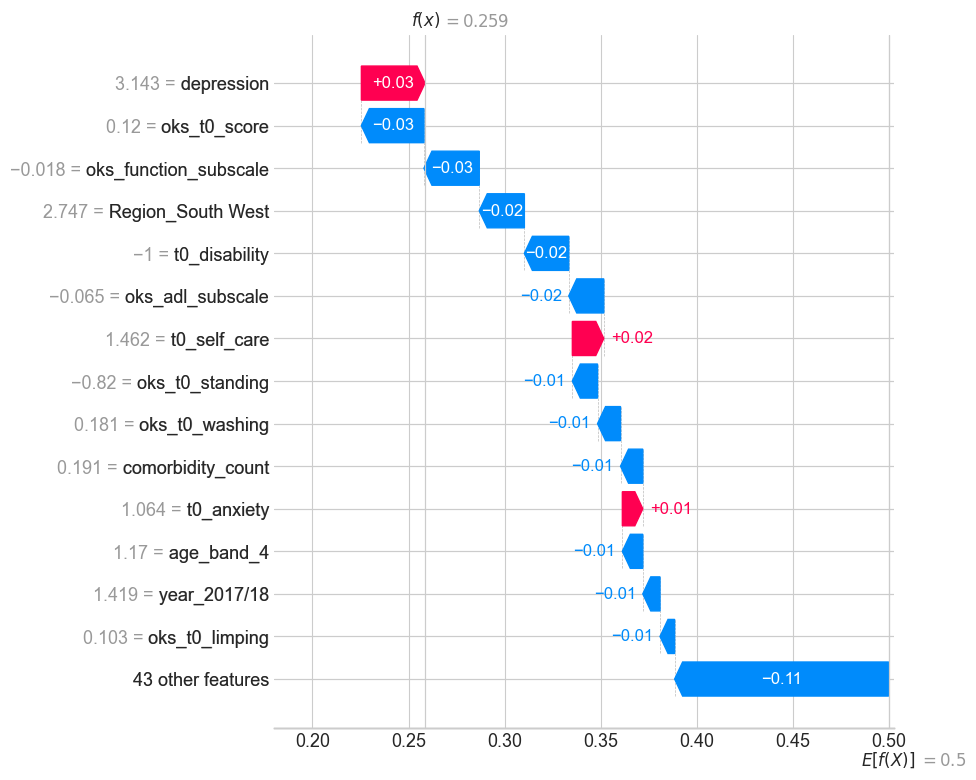

Patient 2 (idx 2) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]


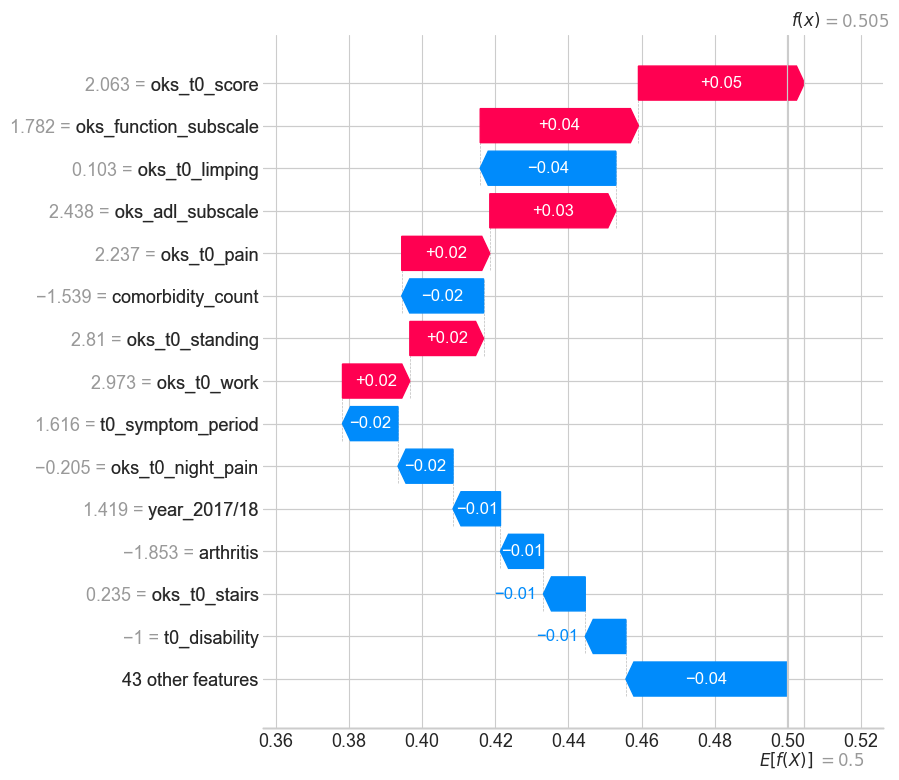

Patient 3 (idx 3) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]


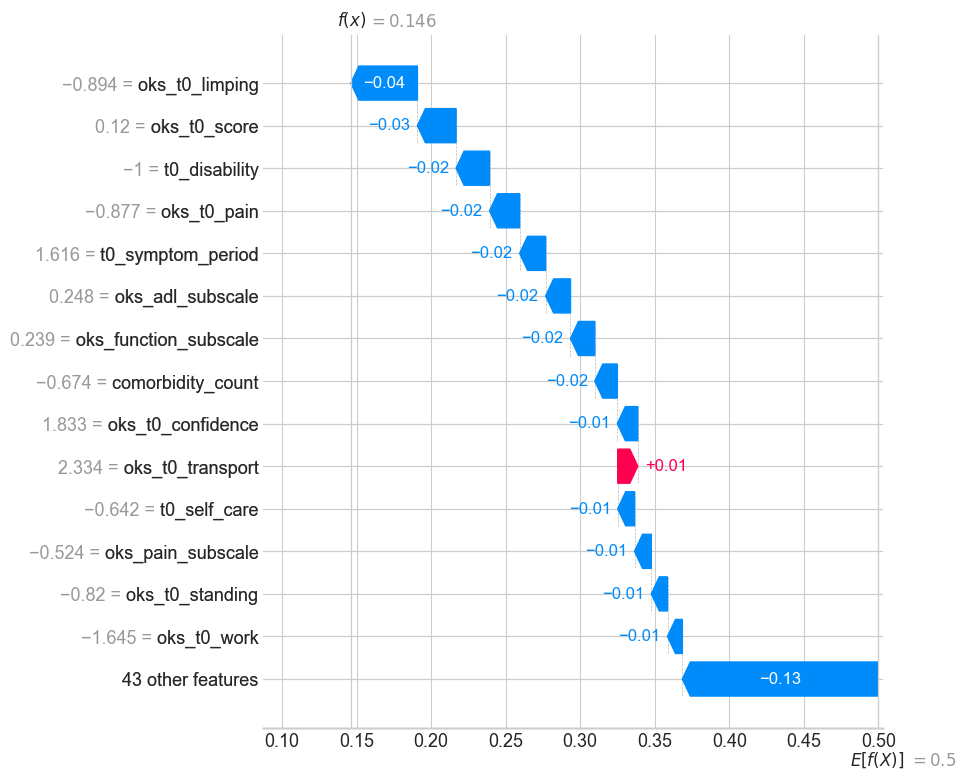

Patient 4 (idx 5) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]


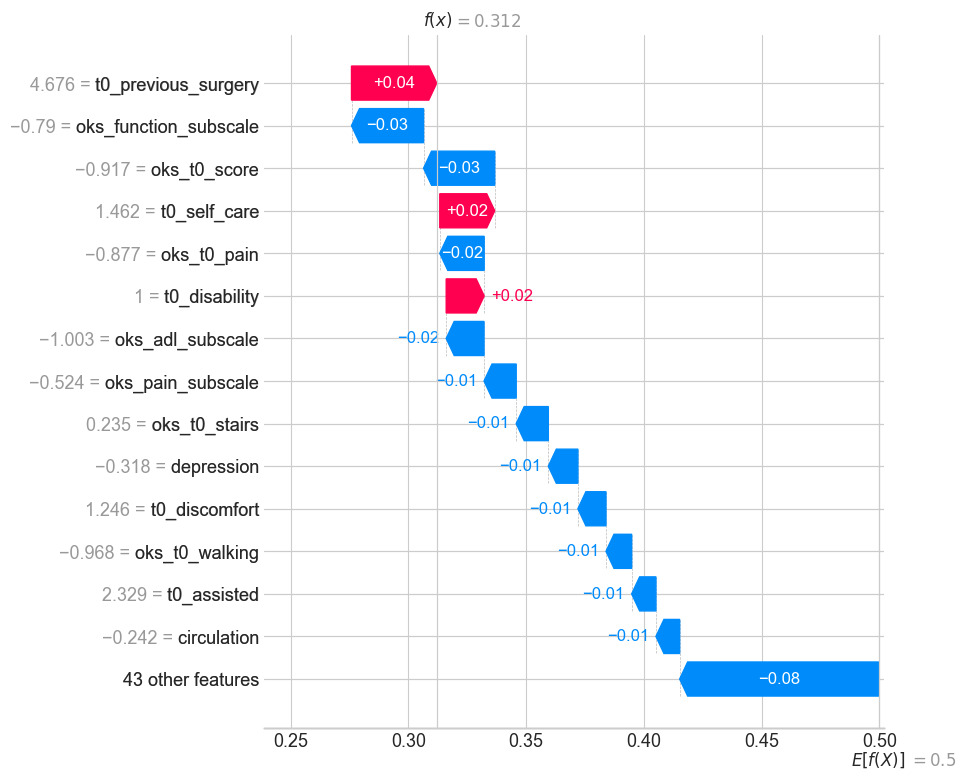

Patient 5 (idx 11) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]


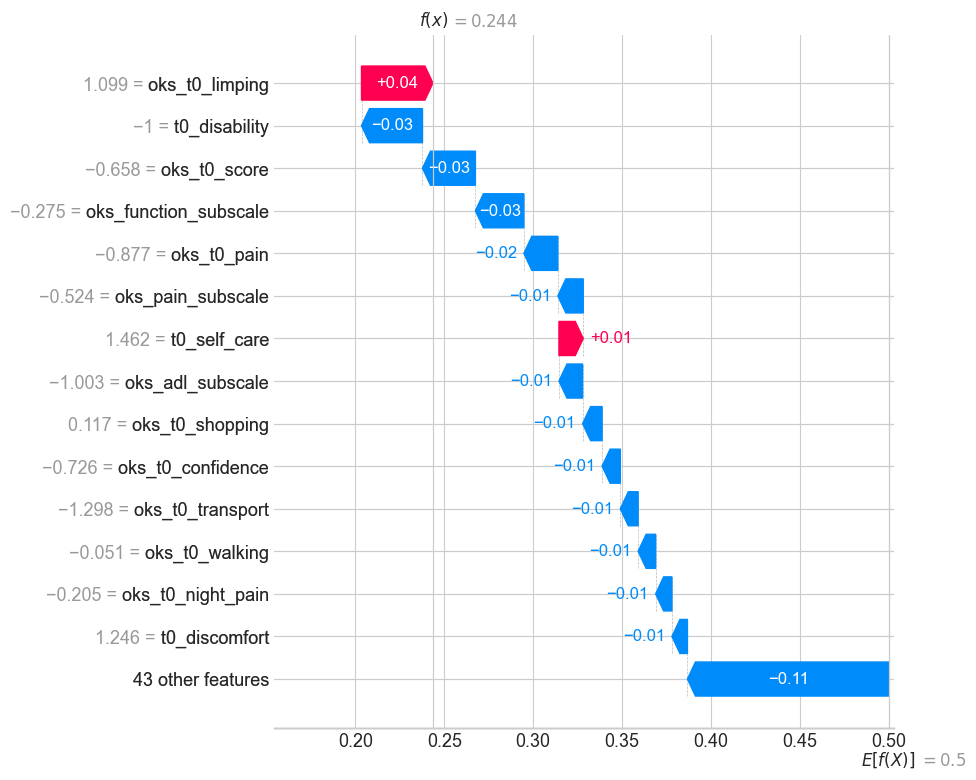

Patient 6 (idx 13) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]


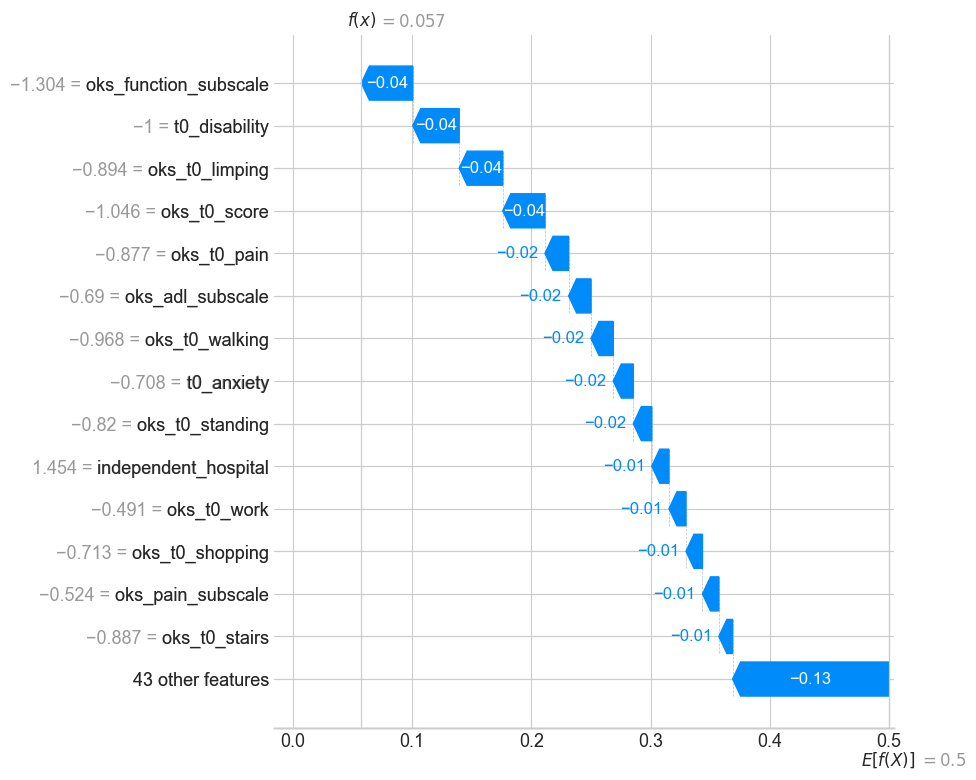

In [40]:
patient_meta = {}
for i, idx in enumerate(patient_indices):
    verdict  = 'CORRECT' if preds[i] == actual_class[i] else 'WRONG'
    act_lbl  = 'Good' if actual_class[i] == 1 else 'Poor'
    pred_lbl = 'Good' if preds[i] == 1 else 'Poor'
    patient_meta[idx] = (
        f'Patient {i+1} (idx {idx})',
        verdict,
        f'Actual: {act_lbl}, Predicted: {pred_lbl}  [threshold={threshold}]'
    )

for i, idx in enumerate(patient_indices):
    name, verdict, details = patient_meta[idx]
    print(f'{name} | {verdict} | {details}')
    shap.waterfall_plot(shap_exp[i], max_display=15, show=True)


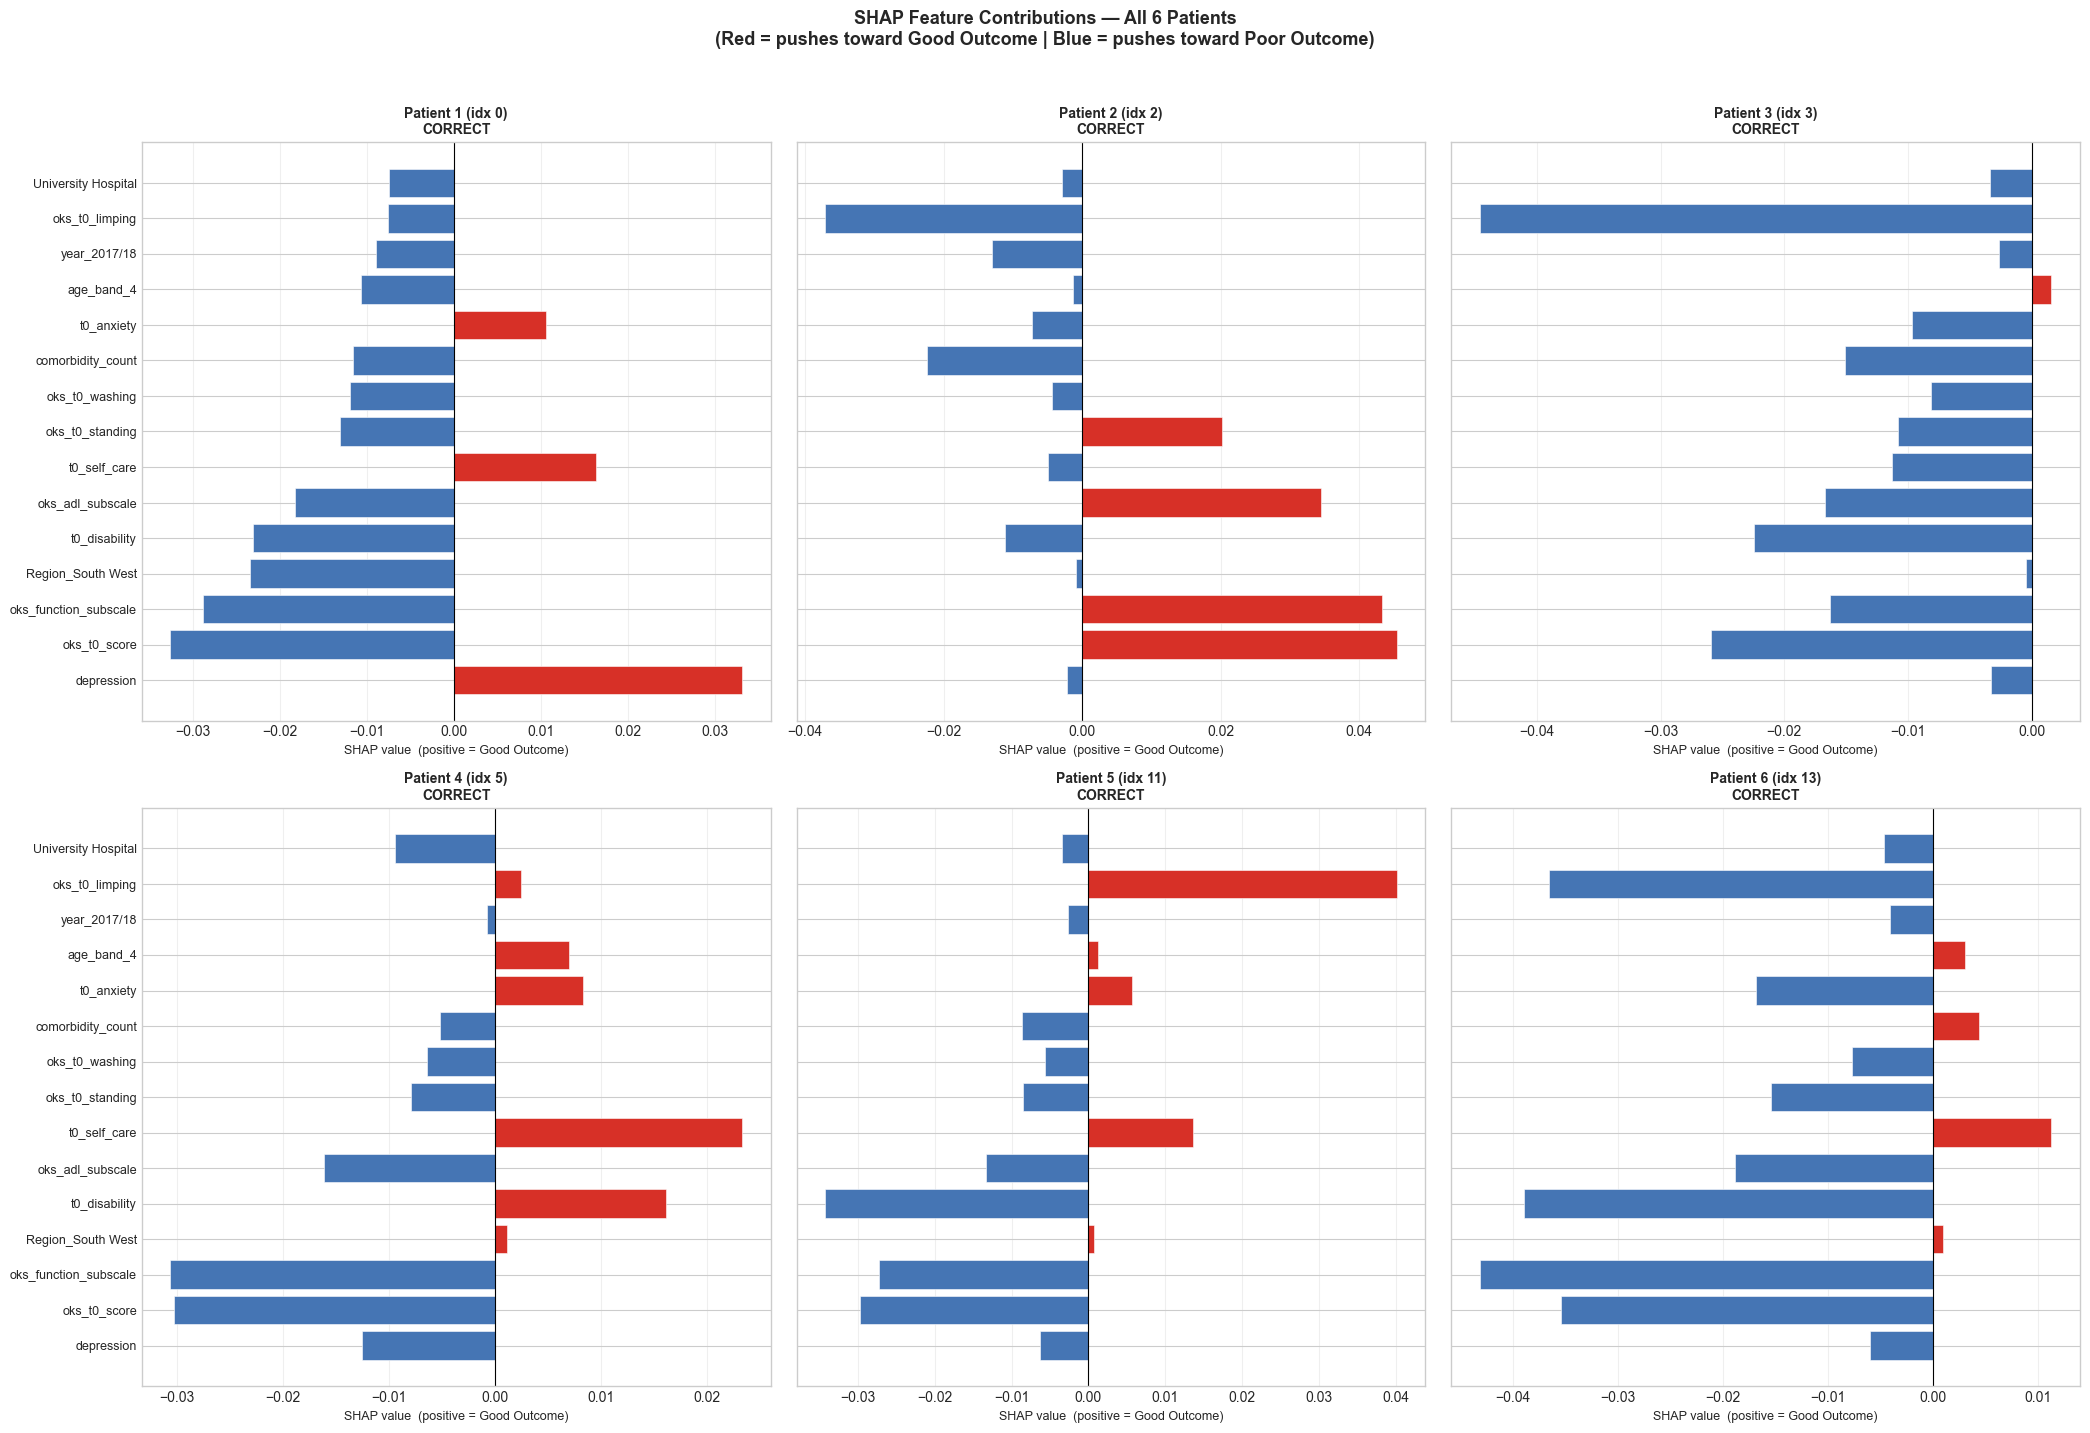

In [41]:
feature_names = patient_data.columns.tolist()
n_top = 15

# Union of top-15 features by |SHAP| across all patients
seen, union_feats = set(), []
for i in range(len(patient_indices)):
    for j in np.argsort(np.abs(shap_vals[i]))[::-1][:n_top]:
        f = feature_names[j]
        if f not in seen:
            union_feats.append(f)
            seen.add(f)
union_feats = union_feats[:n_top]

fig, axes = plt.subplots(2, 3, figsize=(21, 14), sharey=True)
axes = axes.flatten()

for i, (ax, idx) in enumerate(zip(axes, patient_indices)):
    name, verdict, _ = patient_meta[idx]
    feat_idx = [feature_names.index(f) for f in union_feats]
    vals     = shap_vals[i][feat_idx]
    colors   = ['#d73027' if v > 0 else '#4575b4' for v in vals]
    y_pos    = np.arange(len(union_feats))
    ax.barh(y_pos, vals, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(union_feats, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name}\n{verdict}', fontsize=10, fontweight='bold')
    ax.set_xlabel('SHAP value  (positive = Good Outcome)', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(
    'SHAP Feature Contributions — All 6 Patients\n'
    '(Red = pushes toward Good Outcome | Blue = pushes toward Poor Outcome)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


In [42]:
print('Top 10 SHAP contributions per patient (sorted by |SHAP value|)')
print('Positive = toward Good Outcome | Negative = toward Poor Outcome')

for i, idx in enumerate(patient_indices):
    name, verdict, details = patient_meta[idx]
    order = np.argsort(np.abs(shap_vals[i]))[::-1][:10]
    rows = []
    for j in order:
        rows.append({
            'Feature':       feature_names[j],
            'Feature Value': round(float(patient_data_scaled.iloc[i, j]), 3),
            'SHAP Value':    round(float(shap_vals[i, j]), 4),
            'Direction':     'Good Outcome' if shap_vals[i, j] > 0 else 'Poor Outcome',
        })
    df = pd.DataFrame(rows)
    pred_prob = best_rf_model.predict_proba(patient_data.iloc[[i]])[:, 1][0]
    print(f'\n{"="*80}')
    print(f'{name} | {verdict} | {details}')
    print(f'P(Good Outcome) = {pred_prob:.3f} | Base value = {explainer.expected_value[1]:.4f}')
    print(f'{"="*80}')
    print(df.to_string(index=False))


Top 10 SHAP contributions per patient (sorted by |SHAP value|)
Positive = toward Good Outcome | Negative = toward Poor Outcome

Patient 1 (idx 0) | CORRECT | Actual: Poor, Predicted: Poor  [threshold=0.8]
P(Good Outcome) = 0.259 | Base value = 0.4998
              Feature  Feature Value  SHAP Value    Direction
           depression          3.143      0.0331 Good Outcome
         oks_t0_score          0.120     -0.0326 Poor Outcome
oks_function_subscale         -0.018     -0.0288 Poor Outcome
    Region_South West          2.747     -0.0235 Poor Outcome
        t0_disability         -1.000     -0.0231 Poor Outcome
     oks_adl_subscale         -0.065     -0.0182 Poor Outcome
         t0_self_care          1.462      0.0164 Good Outcome
      oks_t0_standing         -0.820     -0.0131 Poor Outcome
       oks_t0_washing          0.181     -0.0120 Poor Outcome
    comorbidity_count          0.191     -0.0116 Poor Outcome

Patient 2 (idx 2) | CORRECT | Actual: Poor, Predicted: Poor  [thre

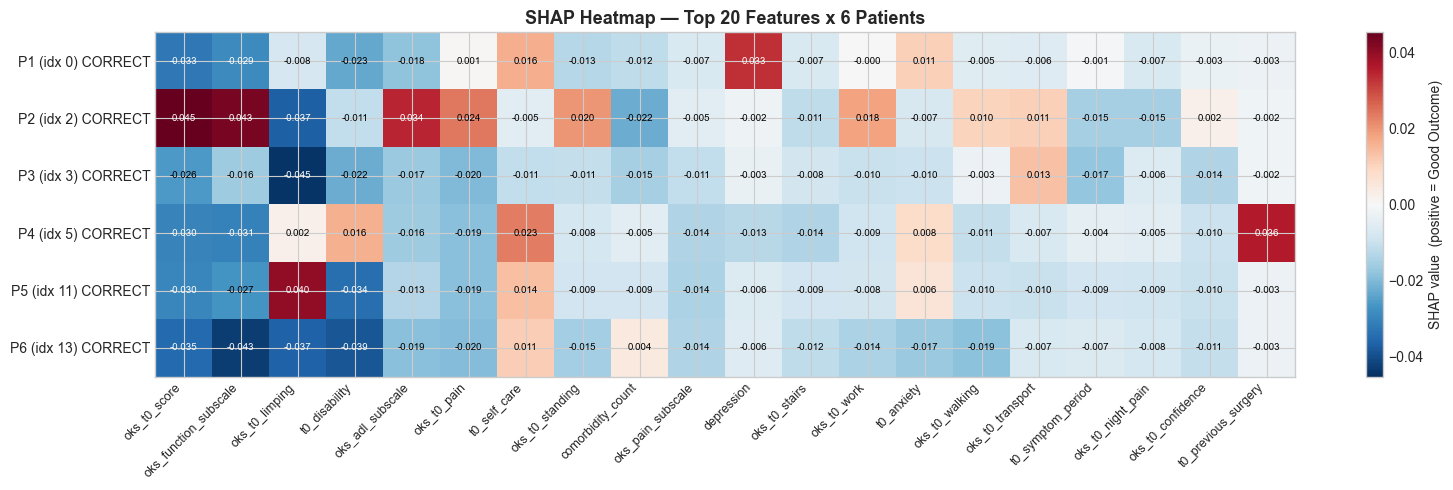

In [43]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top_idx   = np.argsort(mean_abs_shap)[::-1][:20]
top_names = [feature_names[j] for j in top_idx]
shap_matrix = shap_vals[:, top_idx]   # (6, 20)

row_labels = [
    f'P{i+1} (idx {patient_indices[i]}) {patient_meta[patient_indices[i]][1]}'
    for i in range(len(patient_indices))
]

fig, ax = plt.subplots(figsize=(16, 5))
vmax = np.abs(shap_matrix).max()
im = ax.imshow(shap_matrix, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(len(top_names)))
ax.set_xticklabels(top_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(np.arange(len(patient_indices)))
ax.set_yticklabels(row_labels, fontsize=10)
plt.colorbar(im, ax=ax, label='SHAP value  (positive = Good Outcome)')
ax.set_title('SHAP Heatmap — Top 20 Features x 6 Patients', fontsize=13, fontweight='bold')

for r in range(shap_matrix.shape[0]):
    for c in range(shap_matrix.shape[1]):
        col = 'white' if abs(shap_matrix[r, c]) > vmax * 0.6 else 'black'
        ax.text(c, r, f'{shap_matrix[r, c]:.3f}', ha='center', va='center',
                fontsize=7, color=col)

plt.tight_layout()
plt.show()
